# EDA — Fashion-MNIST

Analyse exploratoire du dataset retenu (cf. `HISTORY.md`, décision du 2026-08-04). Suit la checklist "EDA" de `TASKS.md` : format, valeurs manquantes/aberrantes, doublons, équilibre des classes, statistiques de pixels, échantillon visuel.

In [1]:
import hashlib
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torchvision import datasets, transforms

DATA_DIR = Path.cwd().parent / "data" / "raw"
CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]

## 1. Chargement train/test, tailles et format

In [2]:
train_ds = datasets.FashionMNIST(DATA_DIR, train=True, download=True)
test_ds = datasets.FashionMNIST(DATA_DIR, train=False, download=True)

train_images = train_ds.data  # torch.uint8, shape (N, 28, 28)
train_labels = train_ds.targets
test_images = test_ds.data
test_labels = test_ds.targets

print(f"Train : {train_images.shape}, dtype={train_images.dtype}")
print(f"Test  : {test_images.shape}, dtype={test_images.dtype}")
print(f"Labels train dtype={train_labels.dtype}, labels test dtype={test_labels.dtype}")
print(f"Nombre de canaux : 1 (niveaux de gris), résolution : 28x28")

Train : torch.Size([60000, 28, 28]), dtype=torch.uint8
Test  : torch.Size([10000, 28, 28]), dtype=torch.uint8
Labels train dtype=torch.int64, labels test dtype=torch.int64
Nombre de canaux : 1 (niveaux de gris), résolution : 28x28


## 2. Valeurs manquantes / fichiers corrompus ou illisibles

In [3]:
for name, images, labels in (("train", train_images, train_labels), ("test", test_images, test_labels)):
    n_nan = torch.isnan(images.float()).sum().item()
    n_missing_labels = (labels < 0).sum().item()
    print(f"{name}: NaN pixels={n_nan}, labels manquants/négatifs={n_missing_labels}, "
          f"images={len(images)}, labels={len(labels)} (correspondance 1-à-1 : {len(images) == len(labels)})")

train: NaN pixels=0, labels manquants/négatifs=0, images=60000, labels=60000 (correspondance 1-à-1 : True)
test: NaN pixels=0, labels manquants/négatifs=0, images=10000, labels=10000 (correspondance 1-à-1 : True)


Aucune valeur manquante attendue : Fashion-MNIST est un dataset nettoyé et standardisé (fichiers binaires IDX, pas de fichiers image individuels susceptibles d'être corrompus).

## 3. Valeurs aberrantes (dimensions, plage de pixels)

In [4]:
for name, images in (("train", train_images), ("test", test_images)):
    shapes = {tuple(img.shape) for img in images}
    pmin, pmax = images.min().item(), images.max().item()
    out_of_range = ((images < 0) | (images > 255)).sum().item()
    print(f"{name}: shapes uniques={shapes}, pixels dans [{pmin}, {pmax}], hors [0,255]={out_of_range}")

train: shapes uniques={(28, 28)}, pixels dans [0, 255], hors [0,255]=0
test: shapes uniques={(28, 28)}, pixels dans [0, 255], hors [0,255]=0


Toutes les images ont une dimension unique (28, 28) et des pixels dans la plage attendue [0, 255] — aucune valeur aberrante détectée.

## 4. Doublons exacts (hash d'image)

In [5]:
def hash_images(images):
    hashes = [hashlib.md5(img.numpy().tobytes()).hexdigest() for img in images]
    counts = Counter(hashes)
    n_dupes = sum(c - 1 for c in counts.values() if c > 1)
    return n_dupes, len(counts)

train_dupes, train_unique = hash_images(train_images)
test_dupes, test_unique = hash_images(test_images)
print(f"Train : {train_dupes} doublons exacts sur {len(train_images)} images ({train_unique} uniques)")
print(f"Test  : {test_dupes} doublons exacts sur {len(test_images)} images ({test_unique} uniques)")

Train : 0 doublons exacts sur 60000 images (60000 uniques)
Test  : 0 doublons exacts sur 10000 images (10000 uniques)


## 5. Équilibre des classes

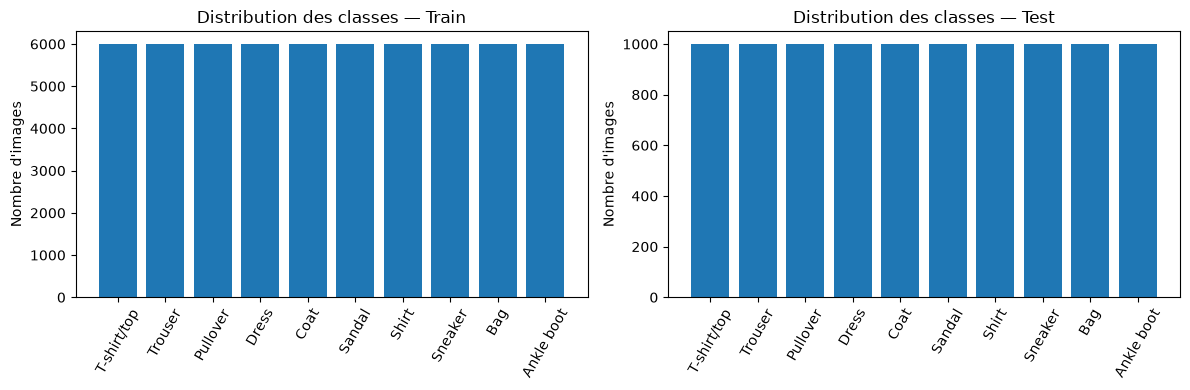

Train par classe : {'T-shirt/top': 6000, 'Trouser': 6000, 'Pullover': 6000, 'Dress': 6000, 'Coat': 6000, 'Sandal': 6000, 'Shirt': 6000, 'Sneaker': 6000, 'Bag': 6000, 'Ankle boot': 6000}
Test par classe  : {'T-shirt/top': 1000, 'Trouser': 1000, 'Pullover': 1000, 'Dress': 1000, 'Coat': 1000, 'Sandal': 1000, 'Shirt': 1000, 'Sneaker': 1000, 'Bag': 1000, 'Ankle boot': 1000}


In [6]:
train_counts = torch.bincount(train_labels)
test_counts = torch.bincount(test_labels)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, counts, title in zip(axes, (train_counts, test_counts), ("Train", "Test")):
    ax.bar(CLASS_NAMES, counts.numpy())
    ax.set_title(f"Distribution des classes — {title}")
    ax.tick_params(axis="x", rotation=60)
    ax.set_ylabel("Nombre d'images")
plt.tight_layout()
plt.show()

print("Train par classe :", dict(zip(CLASS_NAMES, train_counts.tolist())))
print("Test par classe  :", dict(zip(CLASS_NAMES, test_counts.tolist())))

Dataset parfaitement équilibré : 6000 images/classe en train (60000/10), 1000 images/classe en test (10000/10). Pas de rééquilibrage nécessaire.

## 6. Statistiques descriptives des pixels (base pour la normalisation)

In [7]:
train_float = train_images.float() / 255.0
mean = train_float.mean().item()
std = train_float.std().item()
print(f"Pixels (train, normalisés [0,1]) : moyenne={mean:.4f}, écart-type={std:.4f}")
print(f"Pixels (train, échelle [0,255])  : moyenne={mean * 255:.2f}, écart-type={std * 255:.2f}")
print("\nÀ utiliser pour la normalisation diffusion (pixels dans [-1, 1]) : x_norm = (x/255 - 0.5) / 0.5")

Pixels (train, normalisés [0,1]) : moyenne=0.2860, écart-type=0.3530
Pixels (train, échelle [0,255])  : moyenne=72.94, écart-type=90.02

À utiliser pour la normalisation diffusion (pixels dans [-1, 1]) : x_norm = (x/255 - 0.5) / 0.5


## 7. Échantillon d'images par classe

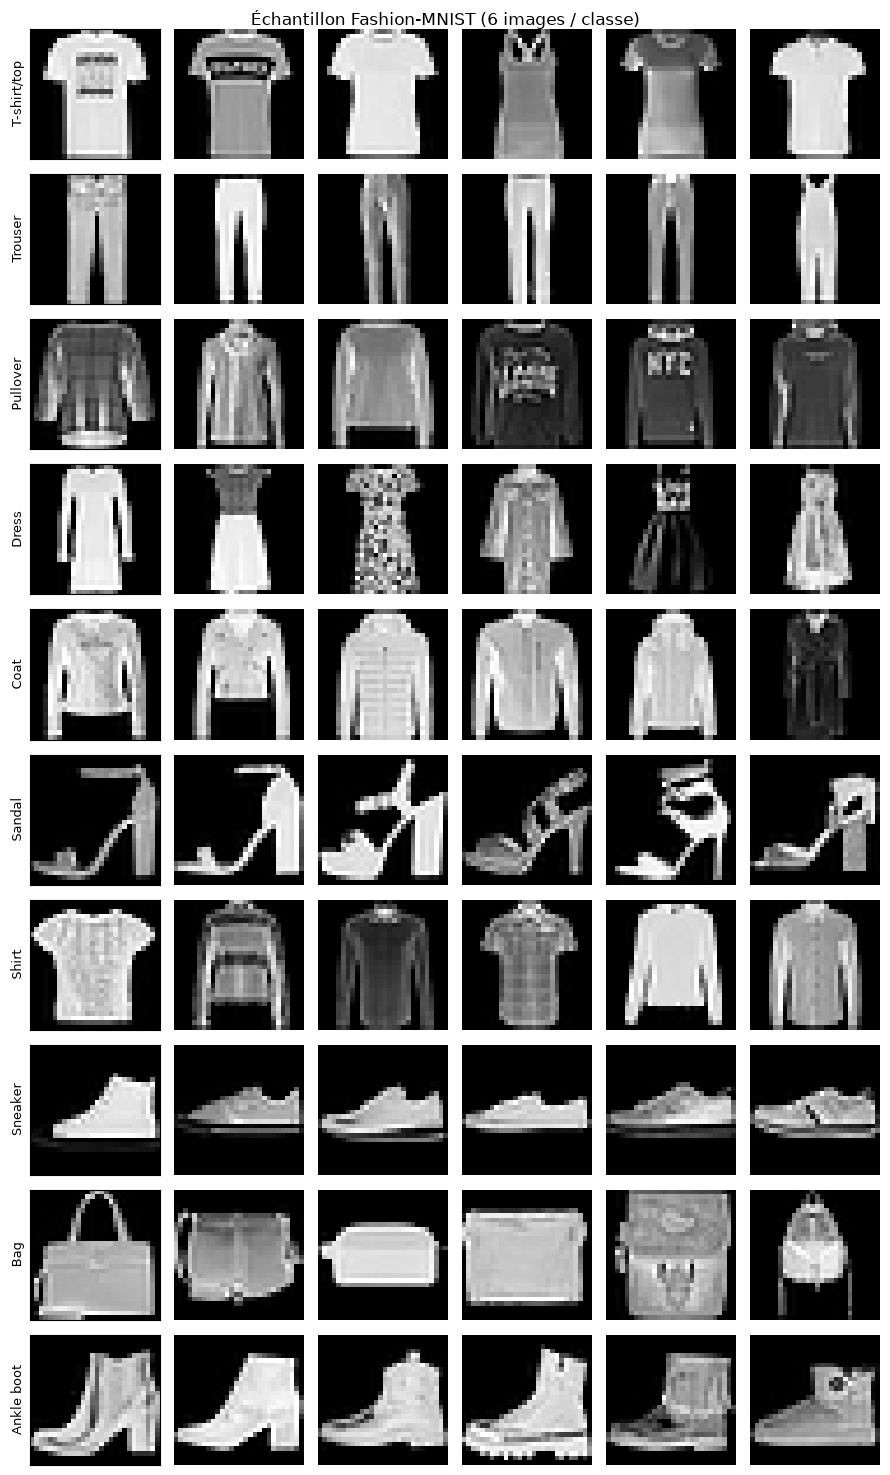

In [8]:
fig, axes = plt.subplots(10, 6, figsize=(9, 15))
rng = np.random.default_rng(42)
for class_idx in range(10):
    idxs = (train_labels == class_idx).nonzero(as_tuple=True)[0]
    sample_idxs = rng.choice(idxs.numpy(), size=6, replace=False)
    for col, img_idx in enumerate(sample_idxs):
        ax = axes[class_idx, col]
        ax.imshow(train_images[img_idx].numpy(), cmap="gray")
        ax.axis("off")
        if col == 0:
            ax.set_ylabel(CLASS_NAMES[class_idx])
    axes[class_idx, 0].axis("on")
    axes[class_idx, 0].set_xticks([])
    axes[class_idx, 0].set_yticks([])
    axes[class_idx, 0].set_ylabel(CLASS_NAMES[class_idx], fontsize=9)
plt.suptitle("Échantillon Fashion-MNIST (6 images / classe)")
plt.tight_layout()
plt.show()

## 8. Observations — base de la section "Données" du rapport

- **Format** : 70000 images en niveaux de gris 28×28 (60000 train / 10000 test), `uint8`, pixels dans [0, 255]. Aucune donnée manquante, aberrante ou dupliquée détectée — dataset propre nativement.
- **Équilibre des classes** : parfaitement équilibré (6000/classe en train, 1000/classe en test), 10 classes de vêtements/accessoires. Pas de biais de classe à corriger.
- **Qualité visuelle** : les classes proches se ressemblent visuellement (`Shirt` vs `T-shirt/top` vs `Coat` vs `Pullover`), ce qui rend la tâche de génération non triviale malgré la simplicité du format — pertinent pour comparer la capacité de DDPM et GAN à capturer des détails fins (manches, cols).
- **Normalisation** : moyenne/écart-type mesurés sur train, à utiliser pour la config `configs/data.yaml`. Pour la diffusion, transformation standard vers [-1, 1] recommandée (`x_norm = (x/255 - 0.5) / 0.5`).
- **Implication pipeline** : pas de resize/crop nécessaire (déjà 28×28, puissance de 2 proche — éventuellement pad à 32×32 pour simplifier les divisions successives par 2 dans le U-Net).